In [ ]:
using Pkg
Pkg.activate(joinpath(pwd(), "plotting_environment"))
# Pkg.instantiate()

In [ ]:
using StatsPlots
using StatsBase

In [ ]:
using Random
using Statistics
using Plots
include("ed.jl")

In [ ]:
H = transverse_ising_hamiltonian(6, 1, 2);
s = get_spectrum(H)
println("gap: ", round(s[2]-s[1], digits =2))
println("bandwidth: ", round(s[end]-s[1],digits=3))

plot(1:length(s), s, seriestype=:line)


In [19]:
bohr = Float64[]
for i in 1:(length(s)-1)
    for j in (i+1):length(s)
        push!(bohr, s[j]-s[i])
        if bohr[end] < 0
            println(i,j, bohr[end])
        end
    end
end
length(bohr)
using StatsBase
median(bohr)

5.4641016151377455

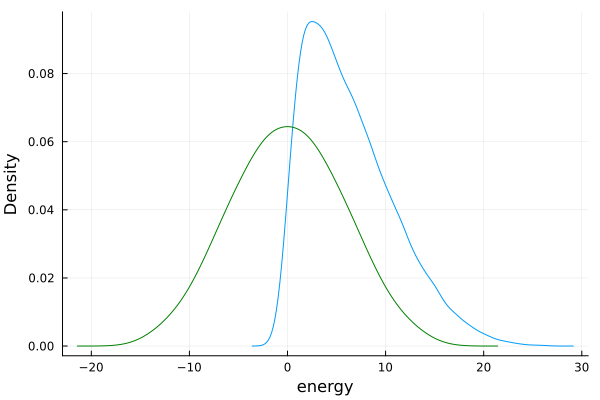

In [34]:
p = density(bohr; legend=false, xlabel="Bohr frequency", ylabel="Density")
density!(p, s; legend=false, xlabel="energy", ylabel="Density", color =:green)

display(p)

In [21]:
using StatsBase

h = fit(Histogram, bohr, nbins=30)
peak_bin = argmax(h.weights)
h.edges[1][peak_bin]

1.0